# Ocean Visions Research Update — the figures

One notebook that draws every figure in the 28 September 2026 Ocean Visions
talk on how ERA5 represents liquid-containing cloud at Utqiaġvik (Barrow).
Nothing is computed here. Every figure is a call into the analysis module
that its working notebook drives, on data loaded by that module's own
`prepare()`, so this notebook and the working notebooks cannot drift apart.

| # | figure | module call | working notebook (section) |
|---|---|---|---|
| 1 | ERA5 seasonal hours against one observed number | `lwph.fig_era5_vs_obs_simple` | `comparison_with_Genie_Obs` (5) |
| 2 | Monthly box-and-whisker, liquid containing, ERA5 vs ARM | `lwph.fig_monthly_box_era5_vs_obs_build` | `comparison_with_Genie_Obs` (7b) |
| 3 | Liquid retention by quality knob, ERA5 vs ARM | `lwph.fig_liquid_retention_by_knob` | `plot_lwp_threshold_sweep` (8) |
| 4 | Distribution of the Taylor horizontal extent | `cse.fig_taylor_hist` | `cloud_spatial_extent` (2) |
| 5 | How often, and how much liquid — maps side by side | `mlh.fig_fraction_and_lwp` | `map_liquid_containing_hours` (5b) |
| 6 | One season month by month, with the ice edge | `mlh.fig_season_monthly_maps` | `map_liquid_containing_hours` (5c) |
| 7 | Normalised surface-flux response to DLR + SW$_{net}$ | `tfr.fig_monthly_response_simple_normalized` | `turbulent_flux_response_to_DLR_and_SW` (4a) |

The modules live in `ERA5/surface_energy_budget/`; the setup cell puts that
directory on `sys.path`. ERA5 is read from the `data/` directory beside the
modules (`storage="local"`) and the ARM observation tables from the same
folder, so nothing is copied here.

## Settings

Each run reproduces its working notebook's `prepare()` call **as it stands
today**. Two settings therefore differ between figures. They are named
constants in the settings cell rather than buried in the calls, so the
difference is visible and can be removed in one place if the talk should be
internally consistent:

- `ice_fraction_min` — the IWP/CWP share at or above which a scene is
  **ice only** (everything water-bearing below it is *liquid containing*).
  **0.90** for figures 1–2, where `comparison_with_Genie_Obs.ipynb` was
  changed from 0.85 on 2026-09-17; **0.85** for figures 3–7, whose notebooks
  still use the older value.
- `min_lwp` — the liquid water path below which liquid counts as absent.
  **0.01 g m⁻²** everywhere except figure 7, whose notebook uses
  **2.0 g m⁻²**. Figure 7 also runs one more season (2014/15–2025/26).

## Cost

Seven streaming passes over the archive — three single-cell runs, one
domain-wide mask, two map runs, one flux-response run — each several
minutes. Load once (the *Load the data* section), then redraw any figure for
free. The whole set is held in memory at once; expect a few GB.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt


def repo_root(start: Path) -> Path:
    """Walk up from ``start`` to the directory holding ``.git``."""
    for p in (start, *start.parents):
        if (p / ".git").exists():
            return p
    raise FileNotFoundError(f"no .git directory above {start}")


# The analysis modules and their data live in ERA5/surface_energy_budget.
# Anchoring on the repository root rather than on this notebook's working
# directory keeps the imports working however Jupyter was launched.
REPO_ROOT = repo_root(Path.cwd().resolve())
SEB_DIR = REPO_ROOT / "ERA5" / "surface_energy_budget"
assert SEB_DIR.is_dir(), f"analysis modules not found at {SEB_DIR}"
if str(SEB_DIR) not in sys.path:
    sys.path.insert(0, str(SEB_DIR))

import plot_lwp_histogram_by_surface_class as lwph   # figures 1-3
import cloud_spatial_extent as cse                   # figure 4
import map_liquid_hours as mlh                       # figures 5-6
import turbulent_flux_response as tfr                # figure 7

# open_mfdataset warns about join/compat defaults changing; the modules pin
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use DPI

# PNGs are written beside this notebook. Set to None to display only.
SAVE_DIR = REPO_ROOT / "Presentations_and_papers" / "Ocean_Visions" / "figures"
DPI = 350                             # saved-file resolution, every figure

## Shared settings

The Barrow region, the eleven October–March cold seasons matching Genie's
2014/15–2024/25 record, the fractional phase scheme and the overcast gate —
copied from the load cell of `comparison_with_Genie_Obs.ipynb`. The
precipitation filter is the one from section 4 of that notebook: ERA5's
`tp` is the rate the published 0.1 mm hr⁻¹ convention is defined on, and an
hour is kept when `tp < 0.05 mm hr⁻¹`. Genie's ver2 seasonal categories are
non-precipitating, so the filtered run is the like-for-like pairing for
figure 1; her monthly spreadsheet includes precipitating cases, so figure 2
uses the unfiltered run.

In [2]:
# Shared by every run below. Any departure from these is made explicitly in
# the load cell that needs it, so the differences between figures are visible.
COMMON = dict(
    region="barrow",
    years=tuple(range(2014, 2025)),   # season START years: 2014/15 .. 2024/25
    season_start=(10, 1),
    season_end=(3, 31),

    phase_mode="fraction",
    liquid_fraction_min=0.90,         # LWP/CWP at or above this = liquid only

    min_lwp=0.01,                     # g m-2, liquid below this counts as absent
    min_iwp=0.01,                     # g m-2, ice below this counts as absent

    min_cloud_fraction=0.95,          # overcast only: tcc >= 0.95
    lsm_tol=0.01,                     # land-sea mask tolerance (module default)
    storage="local",                  # data/ beside the modules
    dpi=DPI,
)

# The precipitation filter from comparison_with_Genie_Obs.ipynb, section 4.
PRECIP = dict(no_precip=True,
              precip_var="rate",      # tp, the quantity the 0.1 mm/hr convention uses
              precip_rate_max=0.05)   # mm hr-1; an hour at or above this is dropped

# IWP/CWP at or above this = ice only. The two working-notebook values -- see
# the header. Set both to one number for an internally consistent talk.
ICE_FRACTION_MIN_COMPARISON = 0.90    # figures 1-2: comparison_with_Genie_Obs
ICE_FRACTION_MIN_DOMAIN = 0.85        # figures 3-7: the other four notebooks

## Load the data

Seven passes, grouped by module. Each is the `prepare()` call of the working
notebook named in the comment, with the shared settings above substituted
for the values it spells out.

### Single-cell runs — figures 1, 2 and 3

`lwph.prepare` streams the archive once, classifies every cell-hour by
surface and phase, and keeps the per-season and per-month hour counts the
comparison figures read. The ARM cell is resolved inside the module
(`surface_class="arm_site"`).

In [3]:
# Figure 1: precipitation filtered -- `A_precip` in comparison_with_Genie_Obs.
A_precip = lwph.prepare(**COMMON, **PRECIP,
                        ice_fraction_min=ICE_FRACTION_MIN_COMPARISON)

removed = A_precip.col["precip_removed"]
before = A_precip.col["cloudy_before_precip"]
print(f"\nprecip filter removed {100 * removed / before:.1f}% of cloudy cell-hours")

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.9 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.9
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%



precip filter removed 14.0% of cloudy cell-hours


In [4]:
# Figure 2: all sky -- `A` in comparison_with_Genie_Obs. Genie's monthly
# spreadsheet includes precipitating cases, so nothing is filtered here.
A_allsky = lwph.prepare(**COMMON, ice_fraction_min=ICE_FRACTION_MIN_COMPARISON)

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.9 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.9
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%


In [5]:
# Figure 3: all sky, with the min_lwp sweep classified inside the same pass --
# `A` in plot_lwp_threshold_sweep.ipynb. Only the liquid floor moves; min_iwp
# is held fixed, so any change along the curve is the liquid threshold alone.
A_sweep = lwph.prepare(
    **COMMON,
    ice_fraction_min=ICE_FRACTION_MIN_DOMAIN,

    sweep_lwp_min=0.1,                # g m-2, low end of the x axis
    sweep_lwp_max=20.0,               # g m-2, high end
    sweep_points=21,                  # all classified in one pass
    sweep_spacing="linear",           # "log" resolves the sub-1 g m-2 region

    show_ice_only=False,              # ice-only rises when liquid gets zeroed
                                      # out of mixed-phase, not when ice grows;
                                      # off so it isn't misread
)

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0

### Domain-wide hourly mask and 10 m wind — figure 4

One pass keeps the hourly liquid-containing mask and the 10 m wind at every
cell — about 1.1 GB for eleven seasons — so that run lengths can be found at
every cell without re-reading the archive. Settings are those of `A_precip`
with the domain value of `ice_fraction_min`, exactly as
`cloud_spatial_extent.ipynb` loads them.

In [6]:
E = cse.prepare_extent(**COMMON, **PRECIP,
                       ice_fraction_min=ICE_FRACTION_MIN_DOMAIN)

# One sample per event: a maximal run of consecutive liquid-containing hours
# at one cell, with L = mean |U10| x run length. exclude_months is left
# empty -- the ARM instrument outages in GENIE_EXCLUDED_MONTHS say nothing
# about ERA5 over the domain.
ev = cse.taylor_events(E)
cse.print_taylor_report(E, ev)

Horizontal extent of liquid-containing cloud, ERA5



  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells
  Cloudy     : tcc >= 0.95   |   cloud liquid water (tclw)   |   non-precipitating: tp < 0.05 mm hr$^{-1}$
  Seasons    : [2014, 2015, 2016, 2017, 20

  Read in 31 s


  ARM cell   : (71.25 N, -156.50 E), 8.9 km E-W x 27.8 km N-S, d_eq of one cell 17.8 km
  Liquid-containing cell-hours: 40,805,366 of 120,348,120 (33.9%)   |   holes in the hourly record: 0


Method 1, Taylor: L = U(10 m) x dt   |   non-precipitating: tp < 0.05 mm hr$^{-1}$
  5,346,670 cell-events over 2,501 cells, 40,805,366 liquid-containing cell-hours, 22,946 censored

  all cells: 5,346,670 events
               median      q25      q75     mean      max
    dt            3.0      1.0      9.0      7.6    310.0   [h]


    U             5.7      4.0      7.8      6.1     25.8   [m/s]
    L            68.0     27.7    180.2    170.2   9415.3   [km]


    L_vec        66.6     27.5    173.7    162.0   9351.0   [km]
    1-h events 27%   |   events >= 24 h 7.1%   |   share of hours in events >= 24 h 39%

  ARM cell: 2,619 events
               median      q25      q75     mean      max
    dt            3.0      1.0      7.0      6.3     91.0   [h]
    U             5.5      3.8      7.9      6.0     18.4   [m/s]
    L            55.0     24.1    141.2    141.0   3305.5   [km]
    L_vec        53.8     24.0    138.2    136.7   3301.1   [km]
    1-h events 31%   |   events >= 24 h 4.8%   |   share of hours in events >= 24 h 30%

  by starting month, all cells   [km unless noted]
    month     events  dt med   U med   L med   L q25   L q75   L p90
    Oct    1,034,008       4     6.2      90      34     258     627
    Nov      978,947       4     5.7      87      33     234     526
    Dec      907,222       3     5.5      64      26     166     371


    Jan      793,870       3     5.6      53      24     135     317
    Feb      746,275       3     5.5      55      24     139     300
    Mar      886,348       3     5.8      62      26     152     314


### Domain maps — figures 5 and 6

`map_liquid_containing_hours.ipynb` draws every map twice, all sky and
precipitation filtered, each carrying a banner naming its setting so no
figure can be mistaken for the other variant. Both runs are kept so either
can go on the slide. The parser is shared with `lwph`, so "the same inputs"
is literal.

In [7]:
M_all = mlh.prepare_maps(**COMMON,
                         ice_fraction_min=ICE_FRACTION_MIN_DOMAIN)             # all sky
M_np = mlh.prepare_maps(**COMMON, **PRECIP,
                        ice_fraction_min=ICE_FRACTION_MIN_DOMAIN)              # filtered

# Every map below is drawn once per entry.
MAP_RUNS = [("all sky", M_all), ("precipitation filtered", M_np)]

removed = 1.0 - M_np.counts["cloudy"].sum() / M_all.counts["cloudy"].sum()
print(f"\nthe filter removes {100 * removed:.1f}% of overcast cell-hours "
      f"across the domain")


  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)

  Reading 11 season(s) on the native 41 x 61 grid: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]



  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)

  Reading 11 season(s) on the native 41 x 61 grid: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]



the filter removes 14.0% of overcast cell-hours across the domain


### Surface-flux response — figure 7

`turbulent_flux_response_to_DLR_and_SW.ipynb` as it stands: twelve seasons
(2014/15–2025/26), `min_lwp = 2.0 g m⁻²`, and the unweighted least-squares
regression as the scatter overlay. The two departures from `COMMON` are
spelled out rather than inherited.

In [8]:
FLUX_SETTINGS = dict(COMMON)
FLUX_SETTINGS.update(
    years=tuple(range(2014, 2026)),   # season START years: 2014/15 .. 2025/26
    min_lwp=2.0,                      # g m-2, liquid below this counts as absent
)

A_flux = tfr.prepare(
    **FLUX_SETTINGS,
    ice_fraction_min=ICE_FRACTION_MIN_DOMAIN,
    fit_mode="regression",            # scatter overlay; changeable without reload
    open_ocean_max_siconc=0.05,       # below this: open ocean
    sea_ice_min_siconc=0.95,          # above this: pack ice; between: MIZ
)

Turbulent flux response to longwave forcing, by surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid-bearing: liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 2/0.01 g m-2
  Precip     : no precipitation filter

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  

## Figure 1 — ERA5 seasonal hours against one observed number

Per season, one stacked bar — ERA5's liquid-containing hours in red, its
ice-only hours on top in blue — and a single dotted line across the axes at
the observed mean of liquid-containing hours per season. The line is a
liquid-containing quantity and is read against the red segments; the blue
keeps the phase split visible.

**Where the line comes from.** `obs_liquid_mean="derived"` (the default)
takes the mean over the **complete** seasons in `genie_arm_seasonal_hours.txt`
— Genie's exact ver2 numbers — following the run's precipitation filter, so
with `no_precip=True` it is her `with_liquid` column alone. Seasons whose
missing hours exceed 5% of the window (2016/17, 2019/20, 2020/21) are left
out, since their hours are lower bounds on what the instruments would have
seen. The legend states the value, its source and how many seasons were
excluded, so the saved PNG records all three.

Source: `comparison_with_Genie_Obs.ipynb`, section 5, *Simplified comparison*.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_era5_vs_obs_simple_noprecip_mean2014-2024 - stacked.png


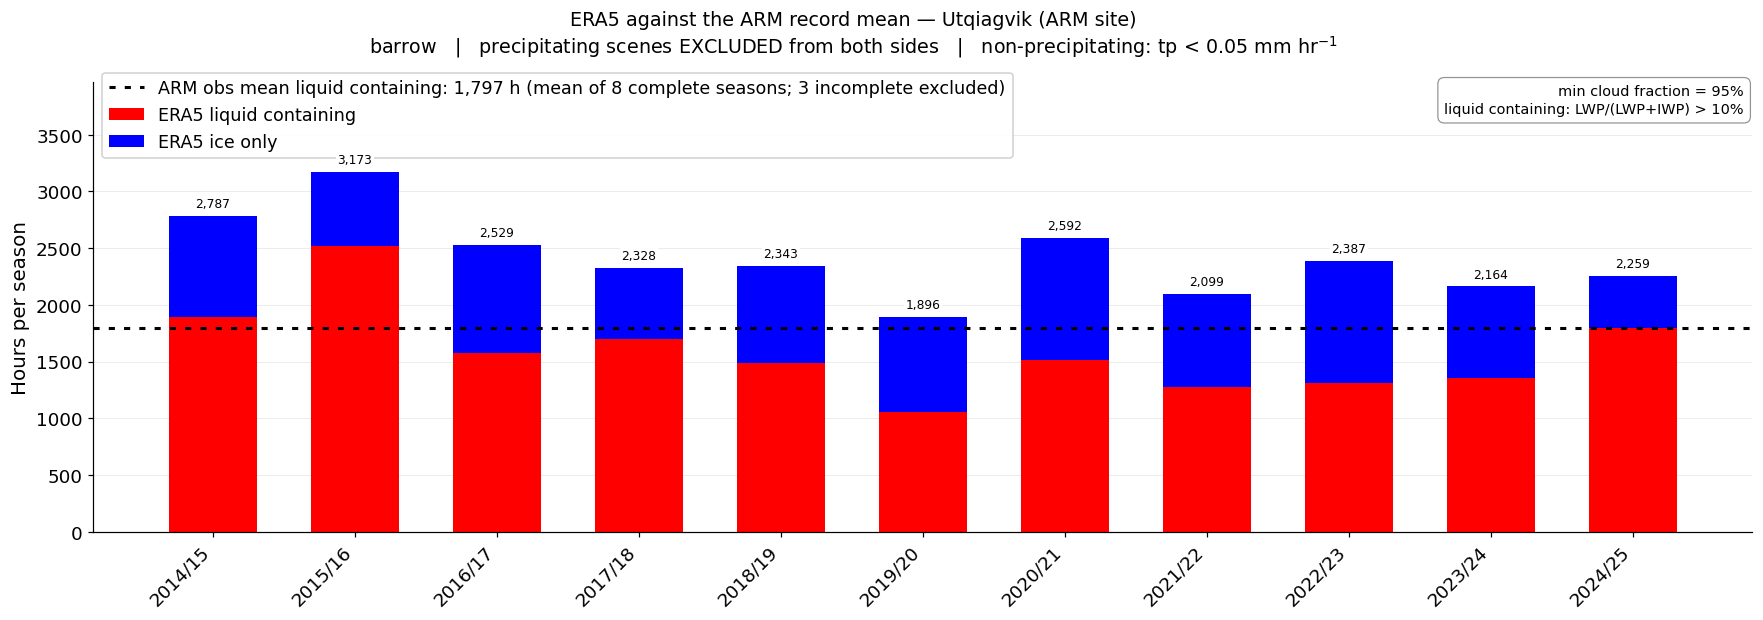

In [9]:
# Derived: the line is the record mean from the saved observation file,
# following A_precip's precipitation filter. The legend states the value.
lwph.fig_era5_vs_obs_simple(A_precip, out_dir=SAVE_DIR, bar_style="stacked");

## Figure 2 — Monthly distributions, box and whisker

Per month, two boxes: ERA5 on the left in **dotted** lines, the observations
from Genie's spreadsheet (`genie_arm_monthly_hours.xlsx`, tab `SUMMARY`) on
the right in solid lines. Each box is the interquartile range across
seasons, the line inside it the median, and the whiskers reach the minimum
and maximum — `whis=(0, 100)`, so no season is drawn as an outlier. The count
under each month is the number of seasons behind the box; the months Genie
highlighted as missing are dropped from **both** sides, which makes it vary
from 9 to 11.

Three frames for the slide build: observations alone, then ERA5 beside them
(these two share one bounding box and overlay exactly), then the
median-difference panel added at its own size. Files carry ` - build1-obs`,
` - build2-both` and ` - build3-full` suffixes.

Source: `comparison_with_Genie_Obs.ipynb`, section 7b.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_box_liquid_containing_era5_vs_obs_mean2014-2024 - build1-obs.png


  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_box_liquid_containing_era5_vs_obs_mean2014-2024 - build2-both.png


  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_box_liquid_containing_era5_vs_obs_mean2014-2024 - build3-full.png


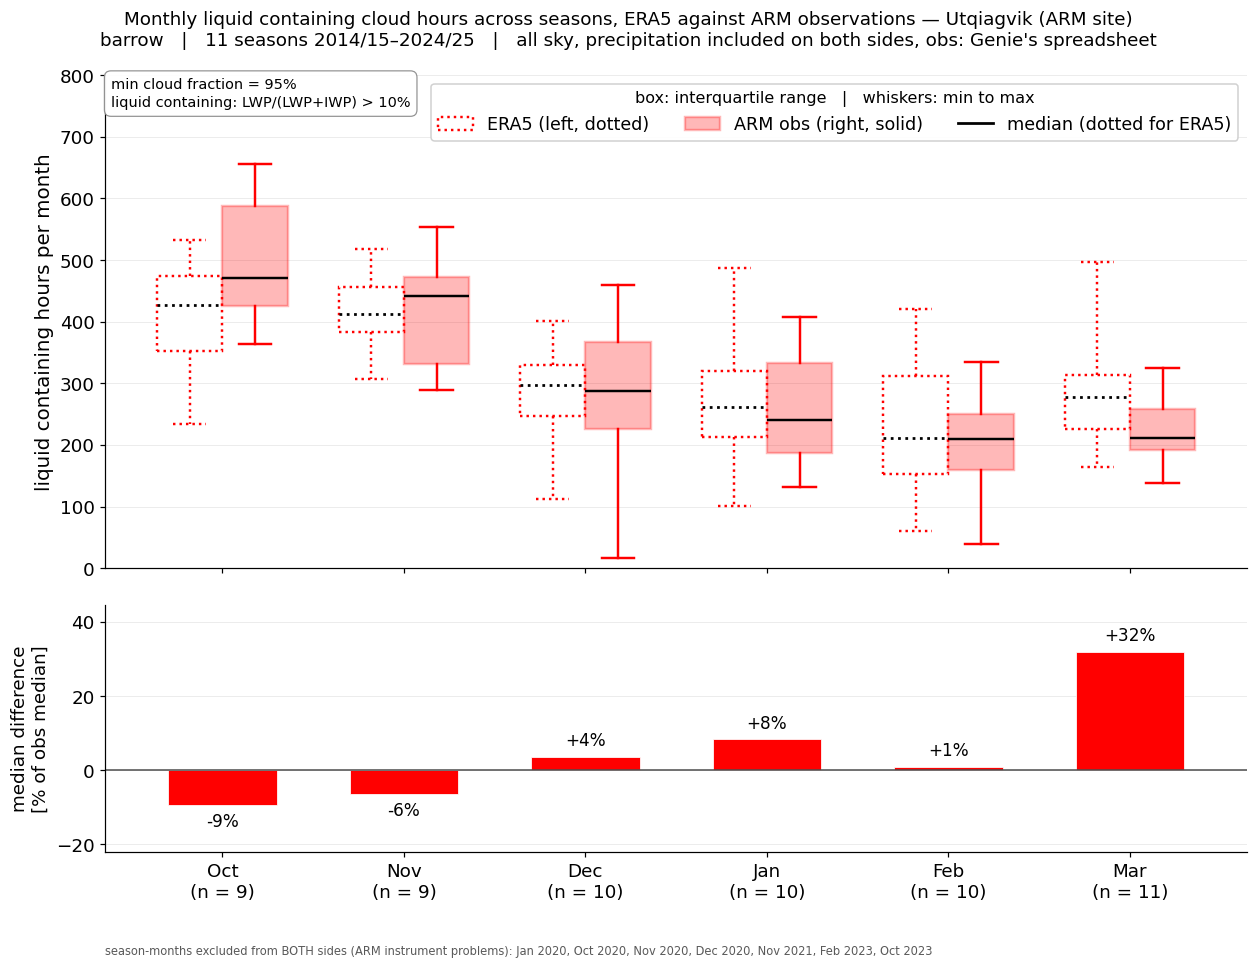

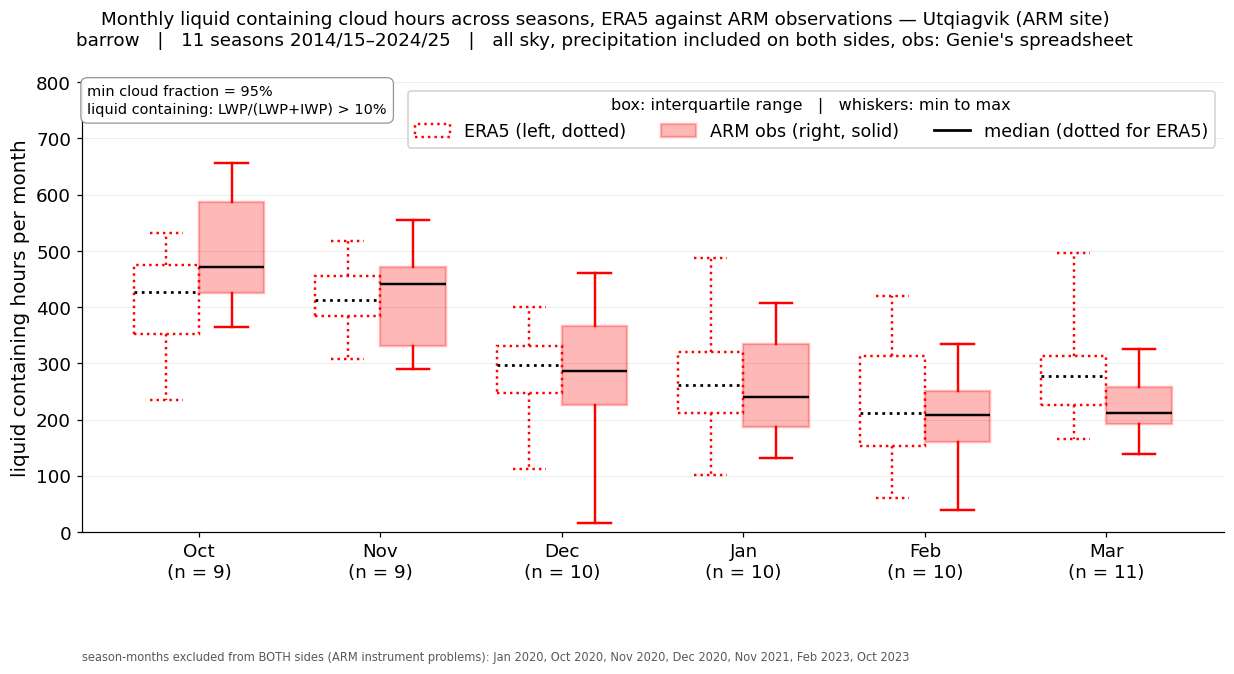

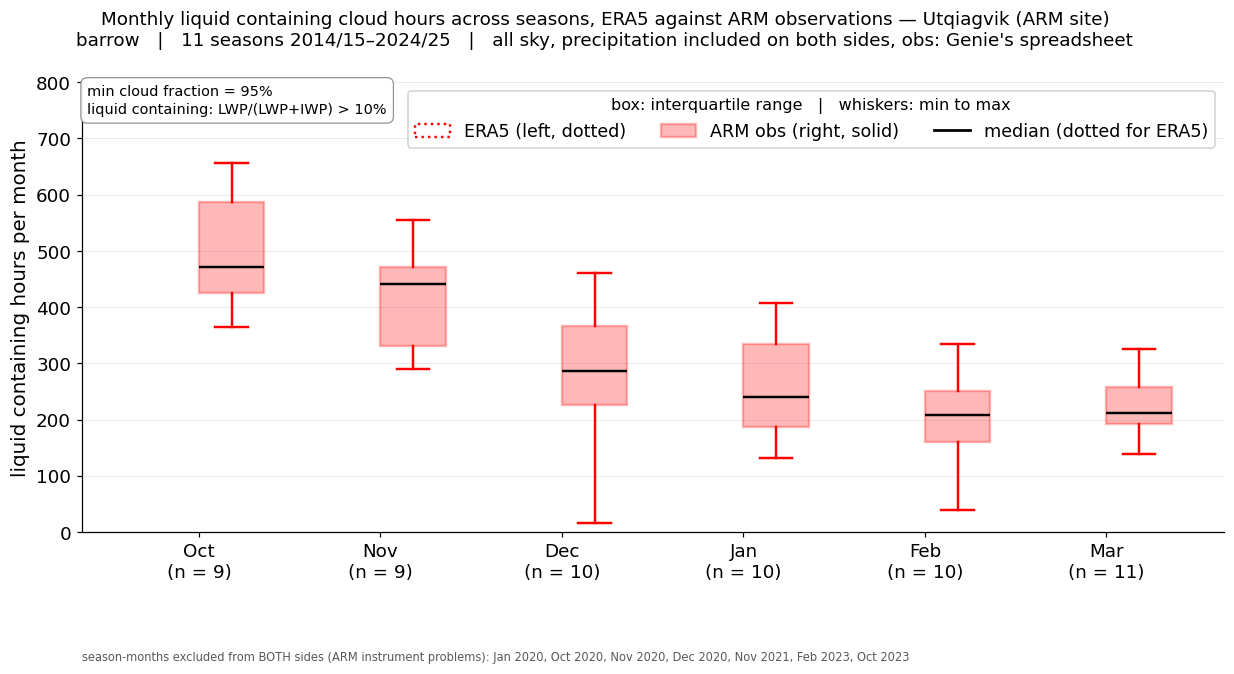

In [10]:
# Liquid containing -- the primary quantity.
b_obs, b_both, b_full = lwph.fig_monthly_box_era5_vs_obs_build(
    A_allsky, out_dir=SAVE_DIR, category="liquid_containing")

## Figure 3 — Liquid retention by quality knob, ERA5 against the ARM record

One knob per panel, both records on it. **(a)** the minimum LWP a scene
must carry to count as liquid containing; **(b)** the minimum duration of a
liquid-containing cloud event, in hours. Observations are the solid line with
filled circles, read from `genie_arm_retained_fraction.txt` (written by
section 6b of the `northSlope_alaska_doeARM` susceptibility notebook from
Genie's ARM analysis); ERA5 is the dashed line with open circles. Each curve
is normalised to its own unfiltered value, so both leave the left edge at
100% and the y axis reads directly as the cost of the threshold.

Below 1 h ERA5 has no curve — its shortest resolvable event is one hour — so
the observed fall inside the first hour has nothing to be compared against.
From 1 h to the end of the observational record both resolve the same
threshold and the comparison is point for point. Pass `dur_xmax_h=8` to zoom
the duration axis onto that overlap.

Source: `plot_lwp_threshold_sweep.ipynb`, section 8, *one panel per knob*.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_liquid_retention_by_knob_mean2014-2024.png


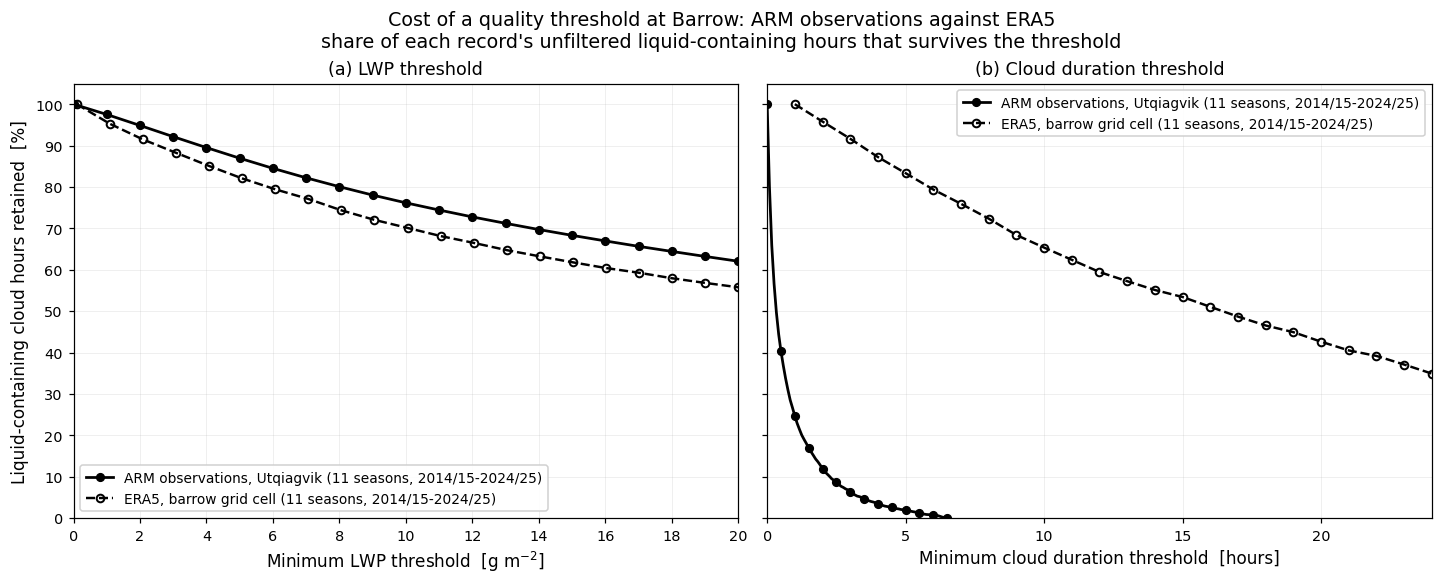

In [11]:
lwph.fig_liquid_retention_by_knob(A_sweep, out_dir=SAVE_DIR);

## Figure 4 — Distribution of the Taylor horizontal extent

Method 1 of the extent notebook. At every cell, a maximal run of
consecutive liquid-containing hours is one **event**, and its horizontal
extent follows Taylor's hypothesis,

$$
L = U_{10}\,\Delta t ,
$$

with $U_{10}$ the mean 10 m wind speed over the run and $\Delta t$ its
duration. One count per event, domain-wide and at the ARM cell, on
log-spaced bins over a log axis: a one-hour event in light wind gives a few
km, a multi-day run thousands. The 10 m wind is slower than the wind at
cloud level, so read $L$ as a lower bound — section 6 of the working notebook
quantifies the ratio from the pressure-level archive.

Source: `cloud_spatial_extent.ipynb`, section 2, *The distribution of L*.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_taylor_hist_L_km_noprecip0p05mmhr_mean2014-2024.png


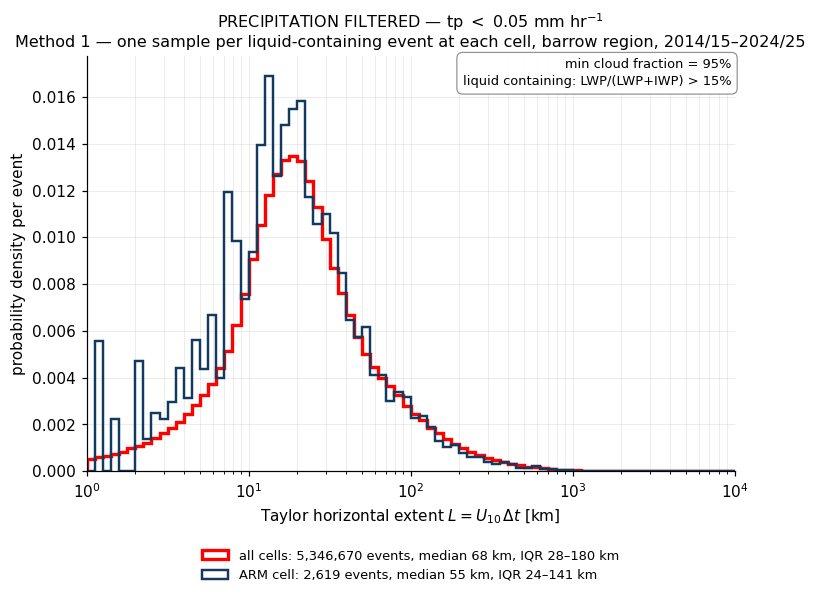

In [12]:
cse.fig_taylor_hist(E, ev, out_dir=SAVE_DIR);

## Figure 5 — How often, and how much liquid — side by side

The season-mean liquid-containing fraction beside the mean LWP of those
clouds, per cell. The two need not vary together: a cell can have liquid
cloud often but thin, or rarely but thick, and the pair separates the two.
The LWP panel is the mean over **every** liquid-containing hour across
seasons — weighted by each season's hour count, not a mean of season means.
Both maps carry latitude/longitude ticks and a margin legend naming the red
star (the ARM cell). Drawn once per run, all sky and precipitation filtered.

Source: `map_liquid_containing_hours.ipynb`, section 5b.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_map_fraction_and_lwp_allsky_mean2014-2024.png


  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_map_fraction_and_lwp_noprecip0p05mmhr_mean2014-2024.png


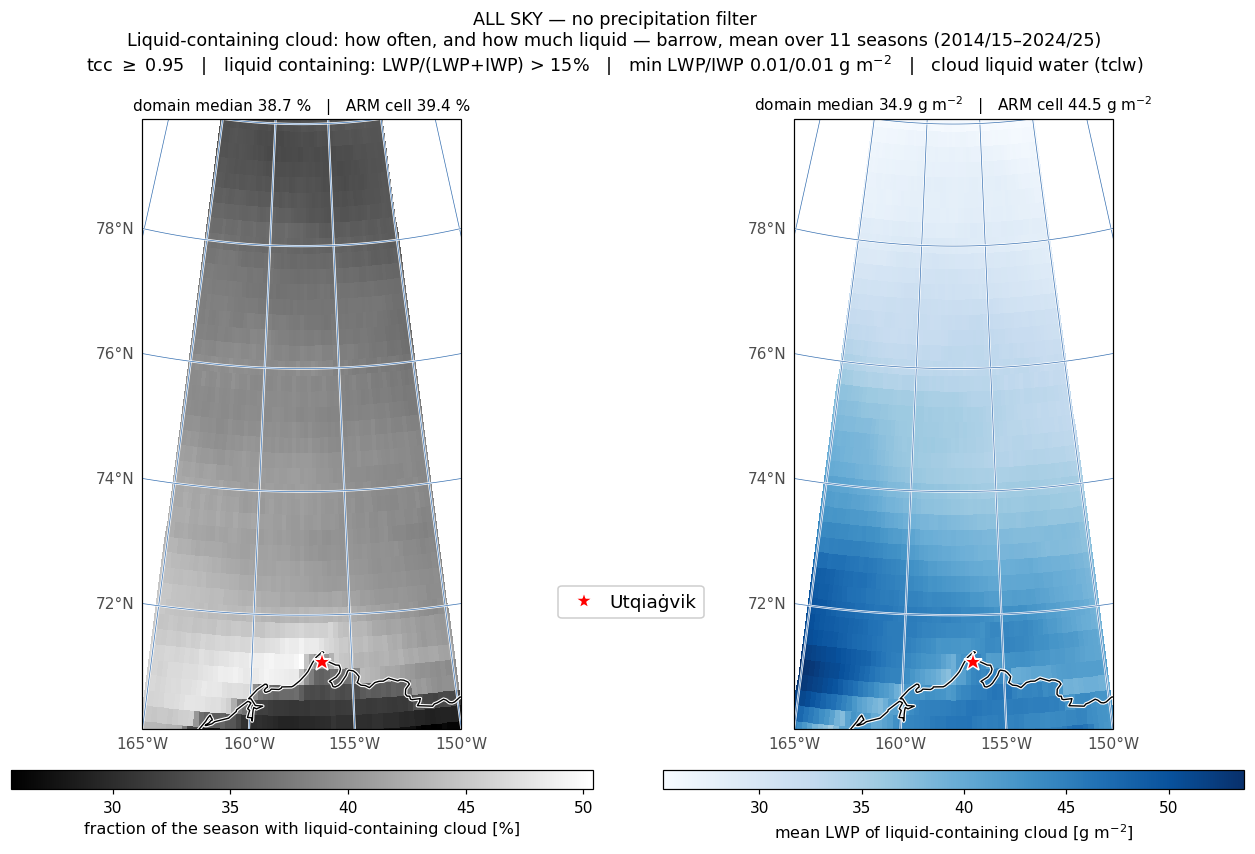

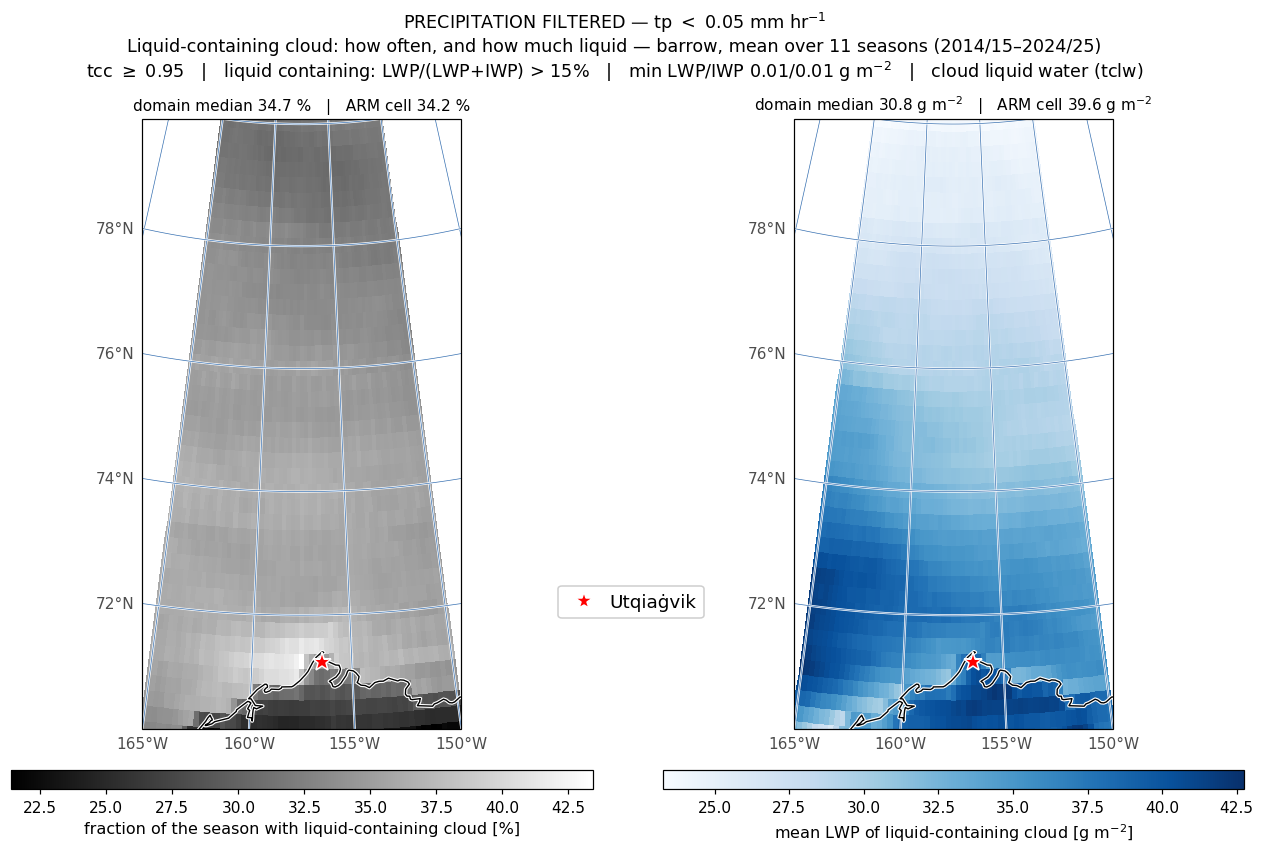

In [13]:
for tag, Mi in MAP_RUNS:
    mlh.fig_fraction_and_lwp(Mi, out_dir=SAVE_DIR)

## Figure 6 — One season month by month, with the ice edge

October through March of one season. **Top row:** fraction of the month with
liquid-containing cloud, per cell, on the same black-to-white scale as the
season maps — a partly sampled month reads as a rate, not a shortfall.
**Bottom row:** mean LWP over those hours, on the white-to-blue scale. Each
row has one colour scale across its six months.

On every panel, the monthly-mean sea ice concentration is contoured —
**dashed at 0.05**, where open water gives way to ice, and **solid at 0.95**,
where full pack ice begins. Those are the concentrations this project's
surface classes are cut at, so the lines are the boundaries between open
ocean, marginal ice zone and sea ice as the season freezes up.

Source: `map_liquid_containing_hours.ipynb`, section 5c.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_map_monthly_2024_allsky_mean2014-2024.png


  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_map_monthly_2024_noprecip0p05mmhr_mean2014-2024.png


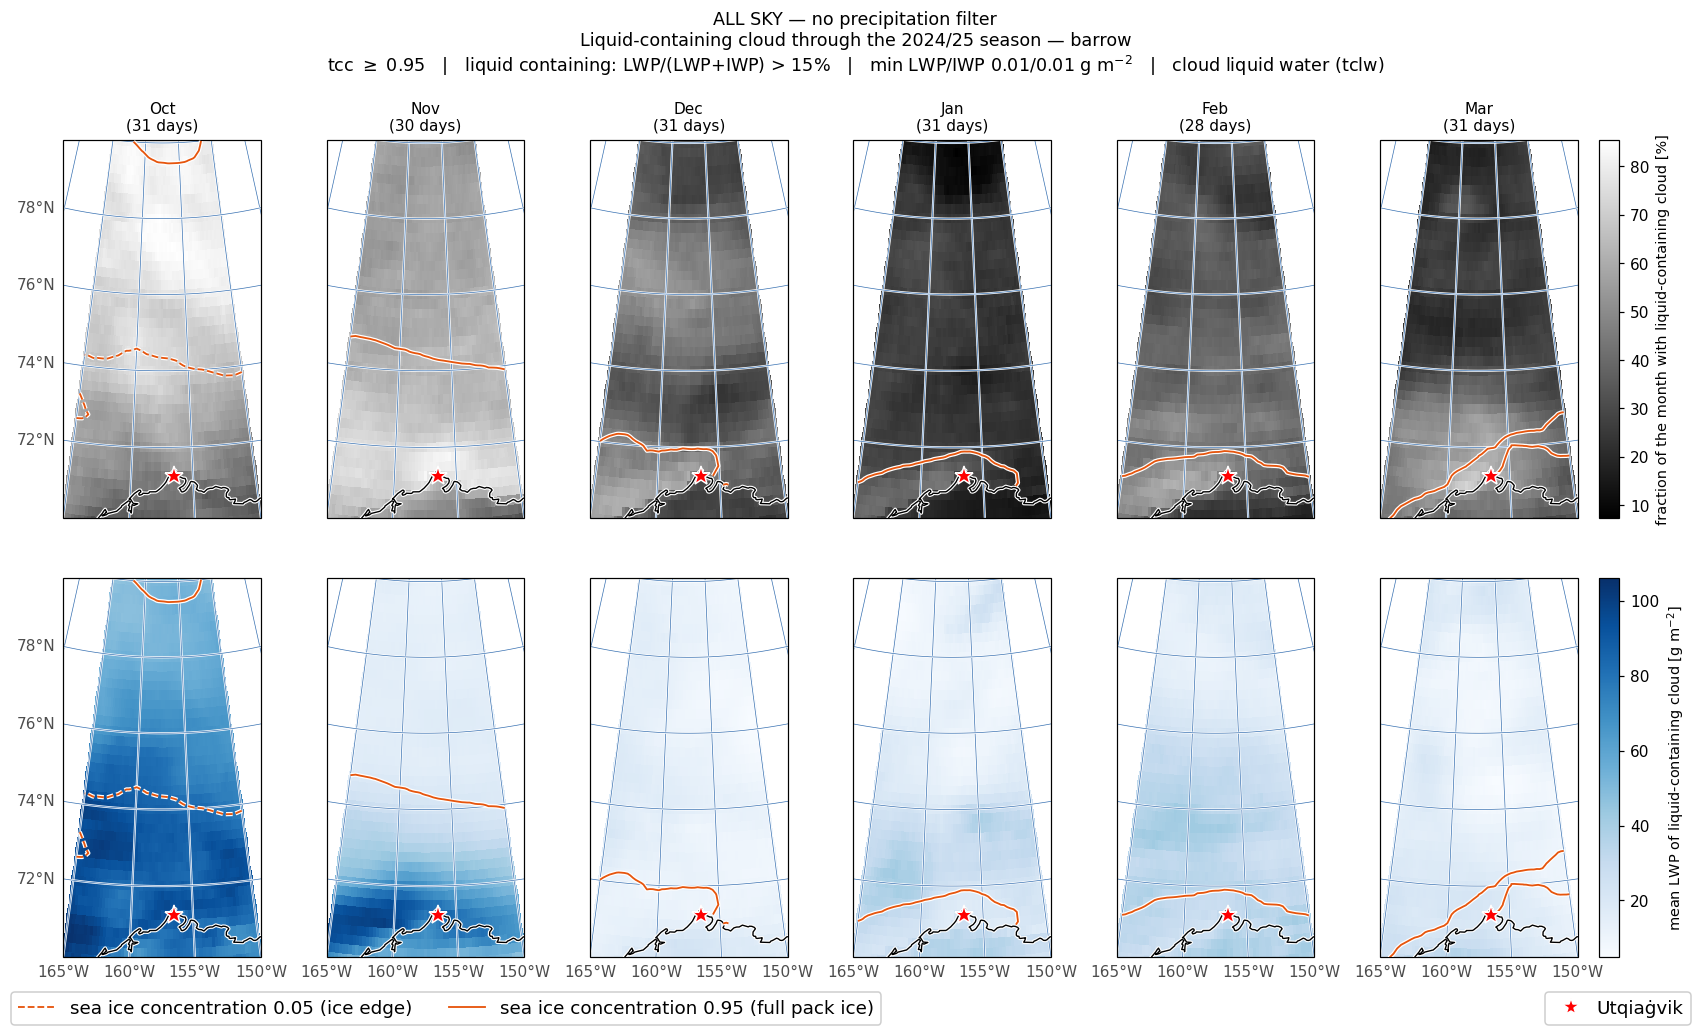

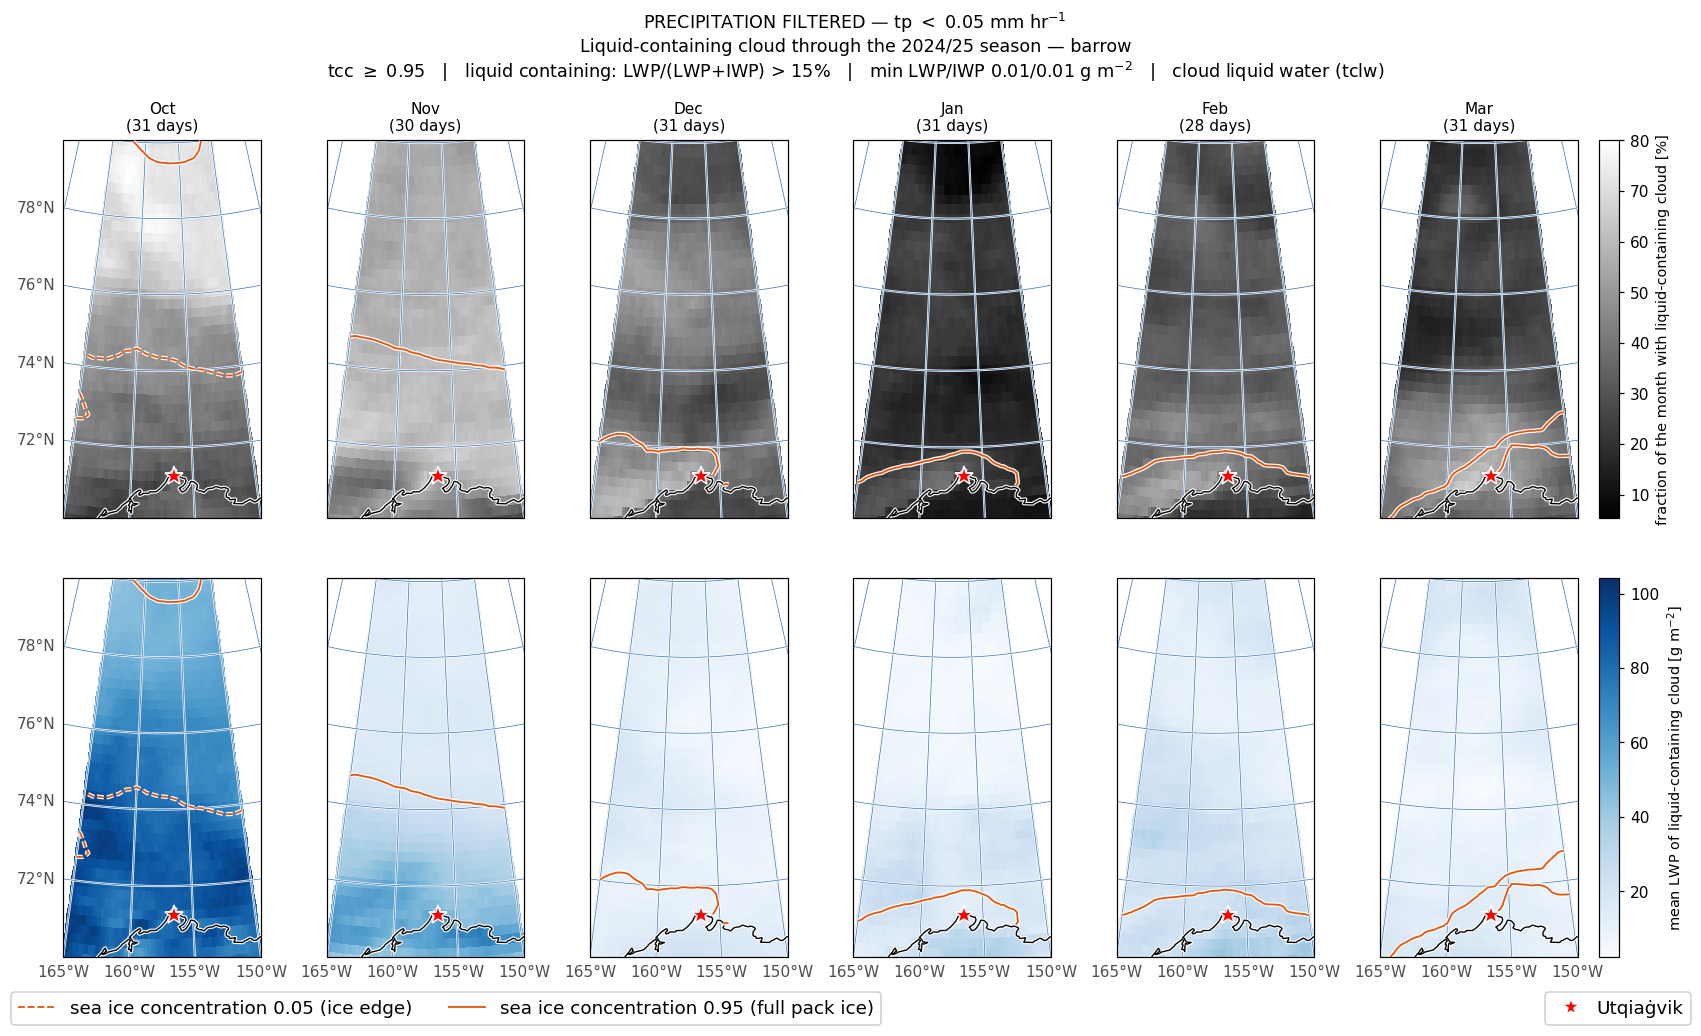

In [14]:
SEASON = 2024      # season start year; any of M_all.used

for tag, Mi in MAP_RUNS:
    mlh.fig_season_monthly_maps(Mi, season=SEASON, out_dir=SAVE_DIR)

## Figure 7 — Normalised surface-flux response to DLR + SW$_{net}$

The slide version of the monthly partition: land, open ocean and sea ice,
each with its own y axis, side by side (`layout="row"` fills the width of a
16:9 slide under its title). Within each (class, month) the four responders
— upwelling longwave, sensible heat, latent heat, and the residual into the
surface — are regressed on the net radiative forcing
$F = \mathrm{DLR} + \mathrm{SW}_{net}$, and each response $f_k$ is divided
by the sum of magnitudes across the terms,

$$
s_k = \frac{|f_k|}{\sum_j |f_j|} ,
$$

so every share lies in $[0, 1]$ and the shares sum to one: the fraction of
the *gross* flux change per W m⁻² of forcing that each channel carries.

**What this is not.** It is not a partition of the forcing. Where every
$f_k$ is non-negative the denominator is one and the shares *are* the
partition; where a channel turns into a source the denominator exceeds one
and every share shrinks. `signed=False` plots the magnitudes, so the figure
no longer shows which channels are sources — read it as activity only.
The sign convention (`convention`, default ERA5: positive is a change in
downward flux) is applied before normalising, and the palette follows the
module default (`palette="sledd"`); `palette="slide"` switches to the
clash-free `MONTHLY_STYLE_SIMPLE` colours.

Source: `turbulent_flux_response_to_DLR_and_SW.ipynb`, section 4a,
*normalised by the sum of magnitudes*.

  -> /Users/andrewbuggee/Documents/VS_CODE/Python-Research/Presentations_and_papers/Ocean_Visions/figures/barrow_monthly_response_simple_norm_fnet_cloud_era5_sledd_abs_wide_mean2014-2025.png


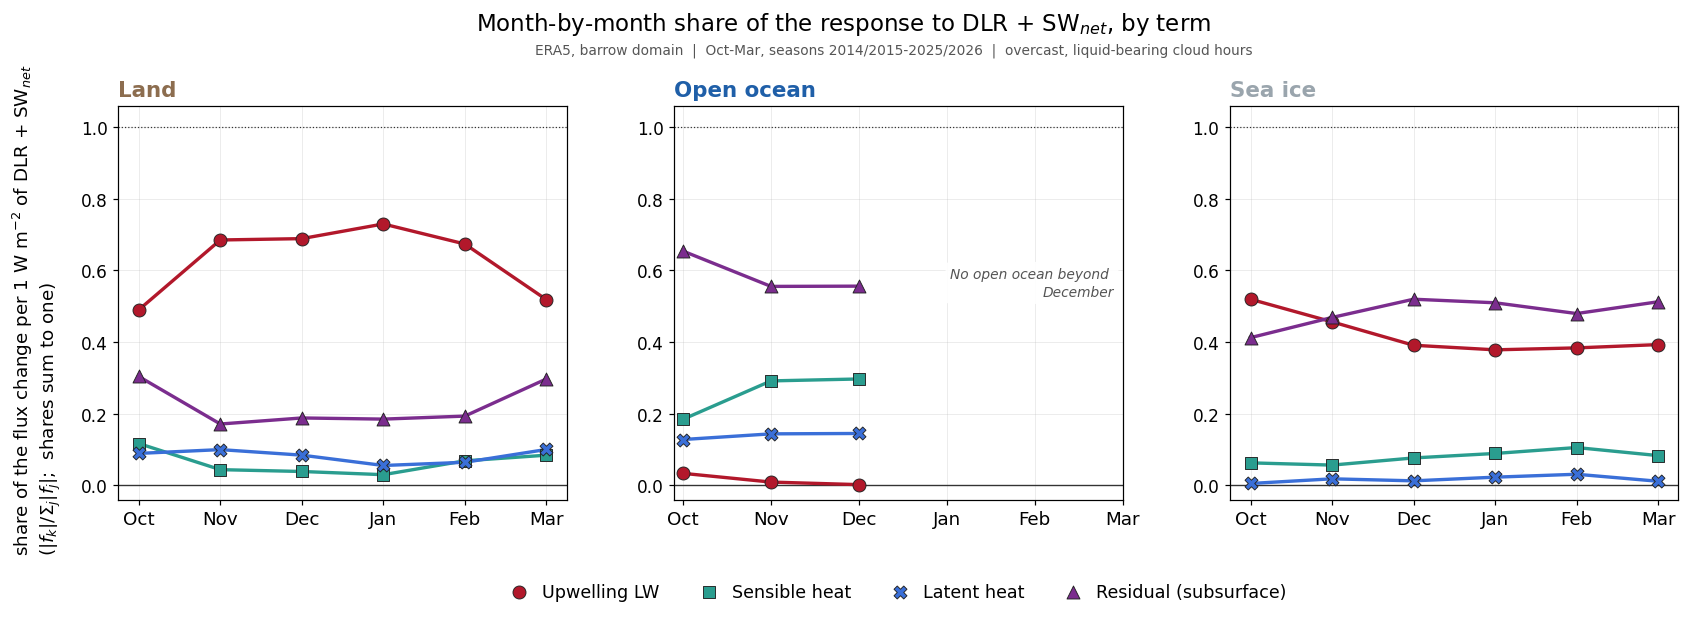

In [15]:
tfr.fig_monthly_response_simple_normalized(
    A_flux, forcer="fnet", layout="row", out_dir=SAVE_DIR, dpi=DPI, signed=False);